# Lesson 3
## MakeMore model

# uses character sequences and attempts to predict the next character (character-level language model)

In [2]:
import sys
from pathlib import Path

# Add the parent directory (nnz2h) to sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

import pygrad

import math
import numpy as np
import matplotlib.pyplot as plt
import random

# jupyter magic:
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines() # set up word analysis

MakeMore looks at the name and the following letters and is trained by looking at a certain letter and using previous names to assess what is likely next (includes the end too)

# Bigram model
2 letters at a time, for example if it starts with a, what is most likely to follow a

In [4]:
for w in words[:1]: # iterates through a word 2 letters at a time
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1,ch2)

e m
m m
m a


In [5]:
for w in words[:1]: # need to make the start and end stand out with special tokens
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>


In [6]:
b = {} # stores the bigrams for analysis later
for w in words: # need to make the start and end stand out with special tokens
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1


In [7]:
sorted(b.items(), key = lambda kv: -kv[1]) # sorts by the frequency rather than letter

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

Python dictonary is not too efficient on larger scales for storing this data, instead we should store in a matrix (what!?!?!?) where first column is the bigram and second is frequency

In [8]:
import torch # import torch for the usage of their tensors

In [9]:
N = torch.zeros((27, 27), dtype=torch.int32) # create initial array

Create a proper way to store the code

In [10]:
chars = sorted(list(set(''.join(words)))) # characters
stoi ={s:i+1 for i,s in enumerate(chars)} # enumerate gives us an iterator over the characters
stoi['.'] = 0 # Special 'start' or 'end' character (typically <#>)
itos = {i:s for s,i in stoi.items()}

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [11]:
for w in words: # need to make the start and end stand out with special tokens
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 # stores frequency of the letter in the matrix

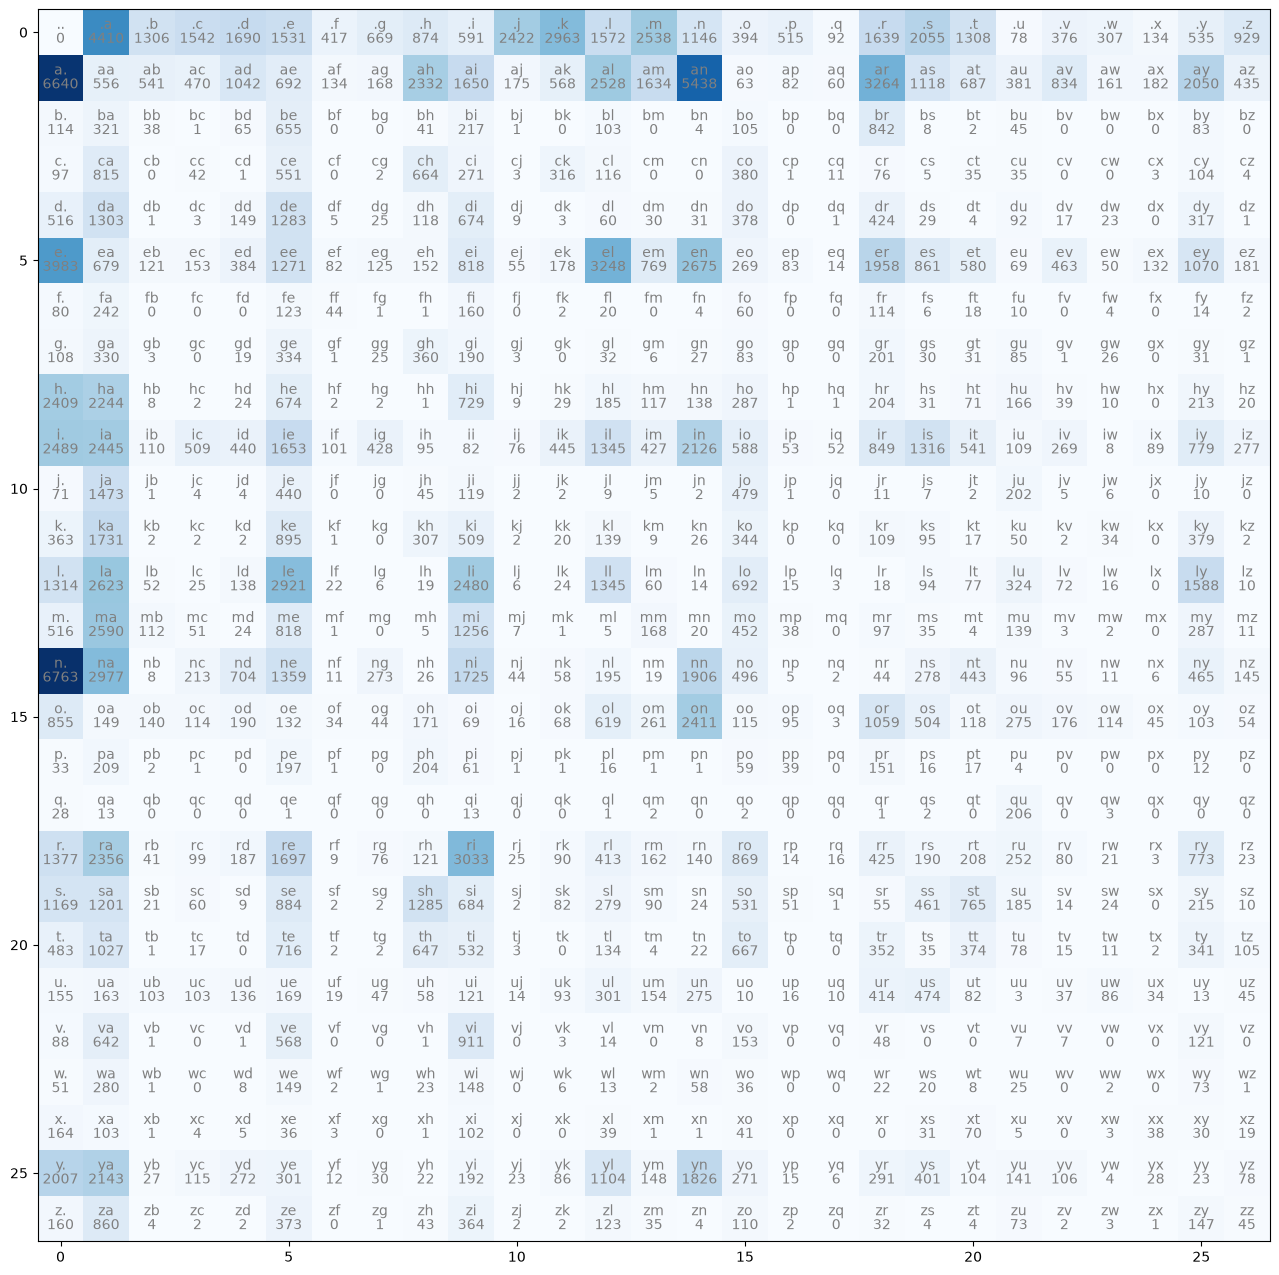

In [12]:

plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color="gray")
        plt.text(j,i,N[i,j].item(),ha="center",va="top",color="gray")

The table will now act as a probability table for prediction in our LLM

In [13]:
p = N[0].float() # porbability of first letter
p = p/p.sum()


In [18]:
# used to create randomized probability
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()


itos[ix]

'a'

In [19]:
p = torch.rand(3,generator=g)
p = p/p.sum()
torch.multinomial(p,num_samples=20,replacement=True, generator=g)

tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0])

This is a very basic bigram run, you will see that its name generation without any guard rails makes it...not the greatest

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(100):

    out = []
    ix = 0 # start token
    while True:
        p = N[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            
            break

    print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.
me.
vifahevara.
jala.
j.
gh.
cryalan.
rlaylmacondo.
pera.
yd.
en.
aienossin.
me.
jancla.
tiesel.
jedahzynaleroneritotturiron.
cri.
alkismeamere.
morad.
lieinaronamnne.
miayuleonteadajeya.
renari.
x.
keika.
s.
ynn.
miudawa.
chahan.
jondelie.
kedariza.
lha.
denoni.
kar.
kavanista.
kesorrlilaa.
lelike.
ssh.
drl.
rcagalaicalasion.
avallciny.
boh.
en.
caikeladeradefwiea.
fes.
malolela.
liy.
elan.
jalinain.
rmayoadish.
con.
alomaruikeee.


In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(100):

    out = []
    ix = 0 # start token
    while True:
        p = torch.ones(27)/27.0
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            
            break

    print(''.join(out))
